In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute          import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import RobustScaler
from sklearn.pipeline        import Pipeline
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import classification_report, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

In [2]:
columns_to_drop = [
    'Timestamp','Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count',
    'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg',
    'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg',
    'Fwd Pkt Len Max', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
    'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Min',
    'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min',
    'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Min',
    'Pkt Len Min', 'Pkt Len Mean', 'Pkt Len Std',
    'Active Mean', 'Active Std', 'Active Min',
    'Idle Mean', 'Idle Std', 'Idle Min',
    'Flow IAT Max', 'Fwd IAT Max', 'Bwd IAT Tot', 'Bwd IAT Max',
    'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Bwd Pkts',
    'Pkt Size Avg', 'Fwd Seg Size Avg', 'Pkt Len Var',
    'Subflow Fwd Pkts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts'
]

In [3]:
csv_files = [
    "02-14-2018.csv", "02-15-2018.csv", "02-16-2018.csv",
    "02-21-2018.csv", "02-22-2018.csv", "02-23-2018.csv"
]
# Store all Malignant and 20% Benign
all_malignant = []
all_benign_sample = []

reference_cols = None   # To check columns consistency

In [4]:
print("Start loading files + clean dirty rows + label mapping...\n")

for file in csv_files:
    print(f"Reading {file} ...")
    df = pd.read_csv(file, low_memory=False)
    
    # === Clean any dirty rows including column name ===
    header_keywords = ['Flow ID', 'Src IP', 'Dst IP', 'Flow Duration', 'Label']
    df = df[~df.apply(lambda row: row.astype(str).str.contains('|'.join(header_keywords), case=False, na=False).any(), axis=1)]
    
    # === replace infinity to numeric and nan===
    df = df.replace(['Infinity', 'NaN', 'nan', 'Infinity '], np.nan)
    
    # change to numeric by columns except Label
    for col in df.columns:
        if col != 'Label':
            df[col] = pd.to_numeric(df[col], errors='coerce')   # if it cannot change to numeric, then change it to NaN
    
    # === Label mapping ===
    df['Label'] = df['Label'].apply(
        lambda x: 'Benign' if str(x).strip() == 'Benign' else 'Malignant'
    )
    
    df = df.drop(columns=columns_to_drop, errors='ignore')
    
    # === 100% Malignant + 20% Benign ===
    malignant = df[df['Label'] == 'Malignant']
    benign_sample = df[df['Label'] == 'Benign'].sample(frac=0.20, random_state=42)
    
    all_malignant.append(malignant)
    all_benign_sample.append(benign_sample)

Start loading files + clean dirty rows + label mapping...

Reading 02-14-2018.csv ...
Reading 02-15-2018.csv ...
Reading 02-16-2018.csv ...
Reading 02-21-2018.csv ...
Reading 02-22-2018.csv ...
Reading 02-23-2018.csv ...


In [5]:
# ====================== Concat ======================
retrain_data = pd.concat(all_malignant + all_benign_sample, ignore_index=True)
print("\n Retrain dataset loaded!")
print(f"Total {len(retrain_data):,} rows")
print(retrain_data['Label'].value_counts())

# ====================== Imputation + Final Cleaning ======================
retrain_data = retrain_data.replace([np.inf, -np.inf], np.nan)
retrain_data['Label'] = retrain_data['Label'].map({'Benign': 0, 'Malignant': 1})

X = retrain_data.drop(columns=['Label'])
y = retrain_data['Label']
imputer = SimpleImputer(strategy="constant", fill_value=0.0)
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

retrain_data = pd.concat([X, y.reset_index(drop=True)], axis=1).drop_duplicates().reset_index(drop=True)
X = retrain_data.drop(columns=['Label'])
y = retrain_data['Label']

print("Imputation + drop_duplicates done！")
print("All features dtype:", X.dtypes.value_counts())


 Retrain dataset loaded!
Total 2,637,425 rows
Label
Malignant    1723919
Benign        913506
Name: count, dtype: int64
Imputation + drop_duplicates done！
All features dtype: float64    31
Name: count, dtype: int64


In [6]:
retrain_data.info()
print(retrain_data['Label'].value_counts())
retrain_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275080 entries, 0 to 1275079
Data columns (total 32 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1275080 non-null  float64
 1   Protocol           1275080 non-null  float64
 2   Flow Duration      1275080 non-null  float64
 3   TotLen Fwd Pkts    1275080 non-null  float64
 4   Fwd Pkt Len Min    1275080 non-null  float64
 5   Bwd Pkt Len Max    1275080 non-null  float64
 6   Flow Byts/s        1275080 non-null  float64
 7   Flow Pkts/s        1275080 non-null  float64
 8   Fwd IAT Tot        1275080 non-null  float64
 9   Fwd PSH Flags      1275080 non-null  float64
 10  Fwd Header Len     1275080 non-null  float64
 11  Bwd Header Len     1275080 non-null  float64
 12  Fwd Pkts/s         1275080 non-null  float64
 13  Bwd Pkts/s         1275080 non-null  float64
 14  Pkt Len Max        1275080 non-null  float64
 15  FIN Flag Cnt       1275080 non-n

,Dst Port,Protocol,Flow Duration,TotLen Fwd Pkts,Fwd Pkt Len Min,Bwd Pkt Len Max,Flow Byts/s,Flow Pkts/s,Fwd IAT Tot,Fwd PSH Flags,...,Down/Up Ratio,Bwd Seg Size Avg,Subflow Fwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Max,Idle Max,Label
0,21.0,6.0,19.0,0.0,0.0,0.0,0.0,1.052632e+05,0.0,0.0,...,1.0,0.0,0.0,26883.0,0.0,0.0,40.0,0.0,0.0,1
1,21.0,6.0,3.0,0.0,0.0,0.0,0.0,6.666667e+05,0.0,0.0,...,1.0,0.0,0.0,26883.0,0.0,0.0,40.0,0.0,0.0,1
2,21.0,6.0,2.0,0.0,0.0,0.0,0.0,1.000000e+06,0.0,0.0,...,1.0,0.0,0.0,26883.0,0.0,0.0,40.0,0.0,0.0,1
3,21.0,6.0,1.0,0.0,0.0,0.0,0.0,2.000000e+06,0.0,0.0,...,1.0,0.0,0.0,26883.0,0.0,0.0,40.0,0.0,0.0,1
4,21.0,6.0,4.0,0.0,0.0,0.0,0.0,5.000000e+05,0.0,0.0,...,1.0,0.0,0.0,26883.0,0.0,0.0,40.0,0.0,0.0,1


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [8]:
# Load model
RF_pipe = joblib.load('RF_spam_filter.pkl')

# Extract the preprocessor and model
preprocessor = RF_pipe.named_steps['preprocessor']
RF_model = RF_pipe.named_steps['RF model']

# Scale new data
X_train_scaled = preprocessor.transform(X_train)
X_test_scaled  = preprocessor.transform(X_test)
X_scaled       = preprocessor.transform(X)

In [9]:
# === Incremental training ===
RF_model.warm_start = True
RF_model.n_estimators += 200 # Add more 200 trees to learn new data

RF_model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=300, warm_start=True)

In [10]:
print("Updated Model Score:", RF_model.score(X_test_scaled, y_test))
prob = RF_model.predict_proba(X_train_scaled)[:, 1]   # Malignant probability
print("Spam / Malignant Probability (first 10):", prob[:10])

Updated Model Score: 0.9997686419675628
Spam / Malignant Probability (first 10): [0.79666667 0.         0.66666667 0.         0.75666667 0.76
 0.01       0.         0.         0.67      ]


In [11]:
print("Start 5-fold Cross Validation...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(RF_model, X_scaled, y, 
                            cv=cv, scoring='accuracy', n_jobs=-1)

print(f"Random Forest 5-fold CV Accuracy: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

Start 5-fold Cross Validation...
Random Forest 5-fold CV Accuracy: 0.9999 (± 0.0000)



=== Random Forest Final Report ===
              precision    recall  f1-score   support

      Benign     0.9996    1.0000    0.9998    161488
   Malignant     1.0000    0.9994    0.9997     93528

    accuracy                         0.9998    255016
   macro avg     0.9998    0.9997    0.9998    255016
weighted avg     0.9998    0.9998    0.9998    255016


Confusion Matrix:
[[161488      0]
 [    59  93469]]


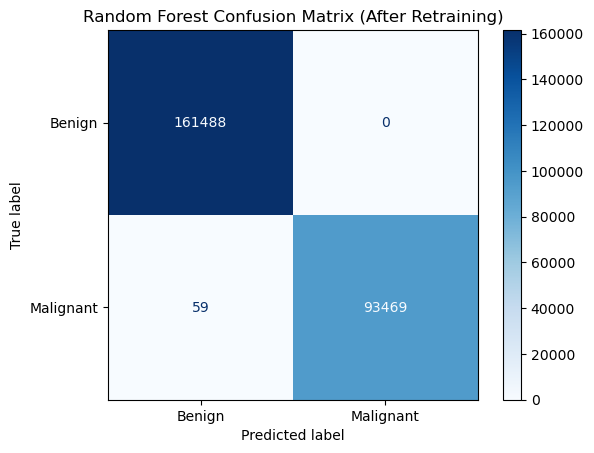

In [12]:
RF_pipe.named_steps['RF model'] = RF_model
y_pred = RF_pipe.predict(X_test)

print("\n=== Random Forest Final Report ===")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant'], digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, 
                                               display_labels=['Benign', 'Malignant'],
                                               cmap='Blues')
plt.title('Random Forest Confusion Matrix (After Retraining)')
plt.show()

In [13]:
RF_pipe.named_steps['RF model'] = RF_model
joblib.dump(RF_pipe, 'RF_spam_filter_350trees.pkl')

['RF_spam_filter_350trees.pkl']

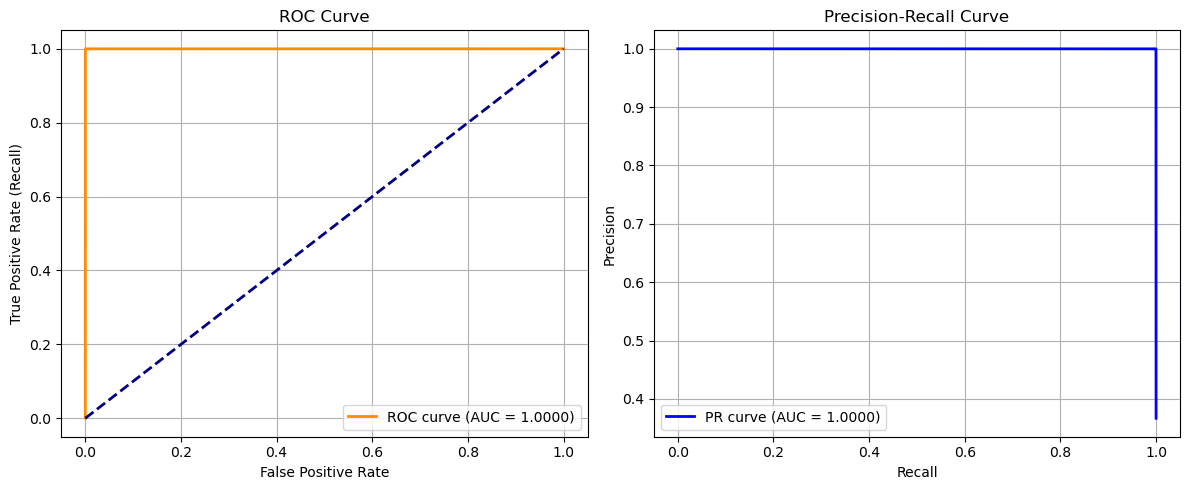

ROC AUC  = 1.0000 
PR AUC   = 1.0000  


In [14]:
probs = RF_model.predict_proba(X_test_scaled)[:, 1]   # Malignant probability

# ====================== ROC Curve ======================
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)

# ====================== PR Curve ======================
precision, recall, _ = precision_recall_curve(y_test, probs)
pr_auc = auc(recall, precision)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"ROC AUC  = {roc_auc:.4f} ")
print(f"PR AUC   = {pr_auc:.4f}  ") 

In [15]:
#del RF_model, X_train_scaled, X_test_scaled, probs